# Lesson 1B: K-Means Practical Applications

## Introduction

You now understand K-Means theory. Time to apply it to **real-world problems**.

K-Means is everywhere:
- **E-commerce**: Customer segmentation for targeted marketing (RFM clustering)
- **Image Processing**: Color quantization and compression
- **Recommendation Systems**: Pre-clustering users for faster neighbor search
- **Genomics**: Gene expression clustering
- **Document Clustering**: Grouping similar texts

In this lesson, we will:
1. Master scikit-learn's KMeans API
2. Apply K-Means to customer segmentation
3. Use silhouette and Davies-Bouldin to choose K on real data
4. Compress images by reducing colors
5. Introduce MiniBatchKMeans for large datasets
6. Benchmark scalability and speed

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [The scikit-learn API](#sklearn-api)
4. [Case Study 1: Customer Segmentation](#customer-segmentation)
5. [Choosing K on Real Data](#choosing-k)
6. [Interpreting Clusters](#interpreting)
7. [Case Study 2: Image Compression](#image-compression)
8. [MiniBatchKMeans for Scalability](#minibatch)
9. [Performance Benchmarking](#benchmarking)
10. [Practical Workflows](#workflows)
11. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from PIL import Image
import time
import io
from typing import Tuple
from numpy.typing import NDArray

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="sklearn-api"></a>
## The scikit-learn KMeans API

### Key Parameters

```python
KMeans(
    n_clusters=8,           # Number of clusters
    init='k-means++',       # Initialization: 'k-means++' or 'random'
    n_init=10,              # How many times to run (return best)
    max_iter=300,           # Max iterations per run
    tol=1e-4,               # Convergence tolerance
    random_state=42         # Seed for reproducibility
)
```

### Important Attributes
- `.cluster_centers_`: Centroid positions
- `.labels_`: Cluster assignment for each point
- `.inertia_`: WCSS of final solution
- `.n_iter_`: Number of iterations
- `.n_features_in_`: Input dimensionality

### Methods
- `.fit(X)`: Train on data
- `.predict(X)`: Predict clusters for new data
- `.fit_predict(X)`: Fit and predict in one call

In [2]:
# Quick example
X, y_true = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42)

kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X)

print(f"Clusters: {kmeans.n_clusters}")
print(f"Centers shape: {kmeans.cluster_centers_.shape}")
print(f"Converged in {kmeans.n_iter_} iterations")
print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print(f"Silhouette: {silhouette_score(X, kmeans.labels_):.3f}")

Clusters: 4
Centers shape: (4, 2)
Converged in 2 iterations
Inertia (WCSS): 564.91
Silhouette: 0.792


<a name="initialization-matters"></a>
## Initialization Matters: `random` vs `k-means++`

Lesson 1A showed *why* K-Means++ initialization helps (from scratch, on a toy
2D dataset). Here's the same effect through the production API, on a harder
case: a dataset with unequal cluster sizes and one small, easy-to-miss
cluster — exactly the kind of data where a single unlucky random init can
converge to a visibly worse local optimum.


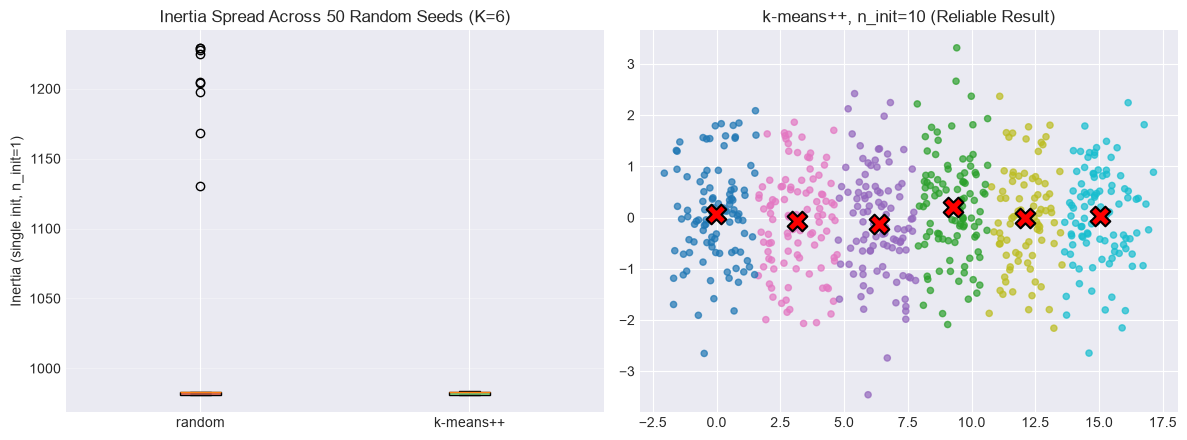

random init  (n_init=1): inertia ranges 981.1 to 1229.2 across 50 seeds (spread=248.1, mean=1021.7)
k-means++    (n_init=1): inertia ranges 981.1 to 984.1 across 50 seeds (spread=3.0, mean=982.3)

k-means++'s spread is 82.9x tighter than random init's — spreading initial centroids apart proportional to squared distance makes it far less likely a single trial 'doubles up' two centroids in one cluster and misses another.
Practical takeaway: scikit-learn defaults to init='k-means++' and n_init=10 — both defaults exist specifically to avoid the bad-seed failure mode shown here.


In [3]:
# A harder dataset: 6 clusters in a line — easy for a random init to "double up"
# two centroids in one blob and miss another, a classic K-Means failure mode
centers = [[i * 3, 0] for i in range(6)]
X_hard, y_hard = make_blobs(n_samples=[100] * 6, centers=centers, cluster_std=1.0, random_state=11)

n_trials = 50
inertias_by_init = {'random': [], 'k-means++': []}

for init_method in inertias_by_init:
    for trial in range(n_trials):
        km = KMeans(n_clusters=6, init=init_method, n_init=1, random_state=trial)
        km.fit(X_hard)
        inertias_by_init[init_method].append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
bp = ax.boxplot(
    [inertias_by_init['random'], inertias_by_init['k-means++']],
    tick_labels=['random', 'k-means++'], patch_artist=True
)
for patch, color in zip(bp['boxes'], ['salmon', 'lightgreen']):
    patch.set_facecolor(color)
ax.set_ylabel('Inertia (single init, n_init=1)')
ax.set_title(f'Inertia Spread Across {n_trials} Random Seeds (K=6)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
km_best = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42).fit(X_hard)
ax.scatter(X_hard[:, 0], X_hard[:, 1], c=km_best.labels_, cmap='tab10', s=20, alpha=0.7)
ax.scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
           c='red', marker='X', s=200, edgecolors='black', linewidths=1.5)
ax.set_title('k-means++, n_init=10 (Reliable Result)')

plt.tight_layout()
plt.show()

random_spread = max(inertias_by_init['random']) - min(inertias_by_init['random'])
kpp_spread = max(inertias_by_init['k-means++']) - min(inertias_by_init['k-means++'])
print(f"random init  (n_init=1): inertia ranges {min(inertias_by_init['random']):.1f} to "
      f"{max(inertias_by_init['random']):.1f} across {n_trials} seeds (spread={random_spread:.1f}, "
      f"mean={np.mean(inertias_by_init['random']):.1f})")
print(f"k-means++    (n_init=1): inertia ranges {min(inertias_by_init['k-means++']):.1f} to "
      f"{max(inertias_by_init['k-means++']):.1f} across {n_trials} seeds (spread={kpp_spread:.1f}, "
      f"mean={np.mean(inertias_by_init['k-means++']):.1f})")
print(f"\nk-means++'s spread is {random_spread / kpp_spread:.1f}x tighter than random init's — "
      f"spreading initial centroids apart proportional to squared distance makes it far less "
      f"likely a single trial 'doubles up' two centroids in one cluster and misses another.")
print(f"Practical takeaway: scikit-learn defaults to init='k-means++' and n_init=10 — "
      f"both defaults exist specifically to avoid the bad-seed failure mode shown here.")


<a name="customer-segmentation"></a>
## Case Study 1: Customer Segmentation (RFM Analysis)

### The Problem

An e-commerce company has customer purchase data. They want to segment customers for targeted marketing:
- **High-value loyal customers**: High recency, frequency, monetary value
- **At-risk customers**: Used to buy frequently but haven't lately
- **New customers**: Recent activity but low frequency/value
- **Inactive customers**: Low on all metrics

**RFM (Recency, Frequency, Monetary)** features capture this. K-Means can automatically discover segments.

In [4]:
# Generate synthetic RFM data
np.random.seed(42)
n_customers = 500

# Recency (days since last purchase, lower is better)
recency = np.concatenate([
    np.random.normal(10, 5, 200),      # Loyal: recent
    np.random.normal(60, 20, 150),     # At-risk: not recent
    np.random.normal(30, 10, 150)      # Casual: medium
])
recency = np.clip(recency, 1, 120)

# Frequency (purchases per year)
frequency = np.concatenate([
    np.random.normal(12, 2, 200),      # Loyal: frequent
    np.random.normal(2, 1, 150),       # At-risk: infrequent
    np.random.normal(4, 2, 150)        # Casual: low-medium
])
frequency = np.clip(frequency, 0, 20)

# Monetary (avg purchase value, $)
monetary = np.concatenate([
    np.random.normal(200, 50, 200),    # Loyal: high spend
    np.random.normal(50, 20, 150),     # At-risk: low spend
    np.random.normal(100, 30, 150)     # Casual: medium spend
])
monetary = np.clip(monetary, 10, 500)

# Create DataFrame
rfm_data = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

print("RFM Customer Data:")
print(rfm_data.head())
print(f"\nShape: {rfm_data.shape}")
print(f"\nStatistics:\n{rfm_data.describe()}")

RFM Customer Data:
     Recency  Frequency    Monetary
0  12.483571  13.852355  269.967772
1   9.308678  15.818833  246.231684
2  13.238443   9.202865  202.981518
3  17.615149  13.125938  167.653161
4   8.829233  10.698715  234.911166

Shape: (500, 3)

Statistics:
          Recency   Frequency    Monetary
count  500.000000  500.000000  500.000000
mean    31.303428    6.655542  129.299942
std     24.531278    4.705614   76.802168
min      1.000000    0.000000   10.000000
25%     11.155276    2.424277   60.843250
50%     24.236391    5.156511  115.725871
75%     46.451449   11.252048  193.536144
max    120.000000   17.146720  321.987620


### Preprocessing: Standardization

In [5]:
# Standardize features (important! Monetary is on different scale than Recency)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

print("Scaled RFM:")
print(rfm_scaled[:5])
print(f"\nMean: {rfm_scaled.mean(axis=0).round(6)}")
print(f"Std: {rfm_scaled.std(axis=0).round(6)}")

Scaled RFM:
[[-0.76794633  1.53094167  1.83339497]
 [-0.89749816  1.94926063  1.52403053]
 [-0.7371437   0.54187913  0.96032925]
 [-0.5585517   1.37641474  0.4998769 ]
 [-0.91706198  0.86008374  1.37648449]]

Mean: [ 0. -0. -0.]
Std: [1. 1. 1.]


<a name="choosing-k"></a>
## Choosing K on Real Data

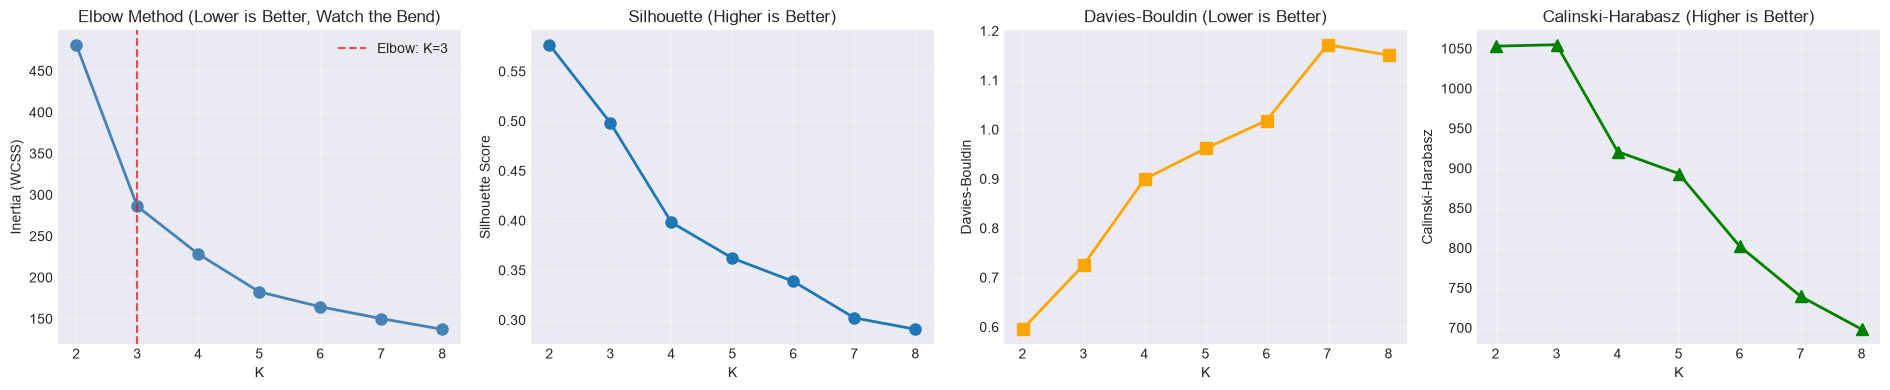

Elbow method suggests K: 3
Best K by silhouette: 2
⚠️  Elbow and silhouette disagree (3 vs 2) — the elbow is a heuristic on inertia alone and can be ambiguous on real, noisy customer data; silhouette (or the downstream business need) should usually settle a tie.


In [6]:
# Test multiple K values
k_range = range(2, 9)
inertias = []
silhouette_scores = []
db_scores = []
ch_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    ch_scores.append(calinski_harabasz_score(rfm_scaled, labels))

# Automatic elbow detection on the inertia curve (second-derivative method)
def find_elbow_point(values: list) -> int:
    """Index (0-based, into k_range) of the steepest turn in a decreasing curve."""
    diffs = np.diff(values)
    diffs2 = np.diff(diffs)
    return int(np.argmax(diffs2)) + 1

elbow_idx = find_elbow_point(inertias)
elbow_k = list(k_range)[elbow_idx]

# Plot
fig, axes = plt.subplots(1, 4, figsize=(19, 4))

ax = axes[0]
ax.plot(k_range, inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
ax.axvline(elbow_k, color='red', linestyle='--', alpha=0.7, label=f'Elbow: K={elbow_k}')
ax.set_xlabel('K')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method (Lower is Better, Watch the Bend)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(k_range, silhouette_scores, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('K')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette (Higher is Better)')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(k_range, db_scores, 's-', linewidth=2, markersize=8, color='orange')
ax.set_xlabel('K')
ax.set_ylabel('Davies-Bouldin')
ax.set_title('Davies-Bouldin (Lower is Better)')
ax.grid(True, alpha=0.3)

ax = axes[3]
ax.plot(k_range, ch_scores, '^-', linewidth=2, markersize=8, color='green')
ax.set_xlabel('K')
ax.set_ylabel('Calinski-Harabasz')
ax.set_title('Calinski-Harabasz (Higher is Better)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print(f"Elbow method suggests K: {elbow_k}")
print(f"Best K by silhouette: {best_k}")
if elbow_k != best_k:
    print(f"⚠️  Elbow and silhouette disagree ({elbow_k} vs {best_k}) — the elbow is "
          f"a heuristic on inertia alone and can be ambiguous on real, noisy customer "
          f"data; silhouette (or the downstream business need) should usually settle a tie.")


<a name="interpreting"></a>
## Interpreting Clusters

In [7]:
# Fit final model
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm_data['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Analyze clusters
print("Cluster Characteristics (original scale):")
print("=" * 70)
for cluster_id in range(4):
    cluster_data = rfm_data[rfm_data['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(cluster_data[['Recency', 'Frequency', 'Monetary']].describe().loc[['mean', 'std']].round(1))

# Segment names (business interpretation)
segment_names = {
    0: "Champions",      # Low recency, high frequency, high monetary
    1: "At-Risk",        # High recency, low frequency, low monetary
    2: "Newcomers",      # Low recency, medium frequency, medium monetary
    3: "Dormant"         # High recency, low frequency, low monetary
}

# Assign segment names
rfm_data['Segment'] = rfm_data['Cluster'].map(segment_names)

print(f"\n\nSegment Distribution:")
print(rfm_data['Segment'].value_counts().sort_index())

Cluster Characteristics (original scale):

Cluster 0 (n=91):
      Recency  Frequency  Monetary
mean     10.8       11.2     158.7
std       4.9        2.1      33.1

Cluster 1 (n=118):
      Recency  Frequency  Monetary
mean     67.9        1.9      49.3
std      15.0        0.9      18.0

Cluster 2 (n=114):
      Recency  Frequency  Monetary
mean      9.4       12.3     241.9
std       4.4        2.0      30.7

Cluster 3 (n=177):
      Recency  Frequency  Monetary
mean     31.6        3.8      95.0
std      10.2        1.9      34.9


Segment Distribution:
Segment
At-Risk      118
Champions     91
Dormant      177
Newcomers    114
Name: count, dtype: int64


### Visualize Segments

<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
/tmp/user/1003/ipykernel_1906411/1753549126.py:17: SyntaxWarning: invalid escape sequence '\$'
  ax.set_zlabel('Monetary (\$)')
/tmp/user/1003/ipykernel_1906411/1753549126.py:29: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel('Monetary (\$)')


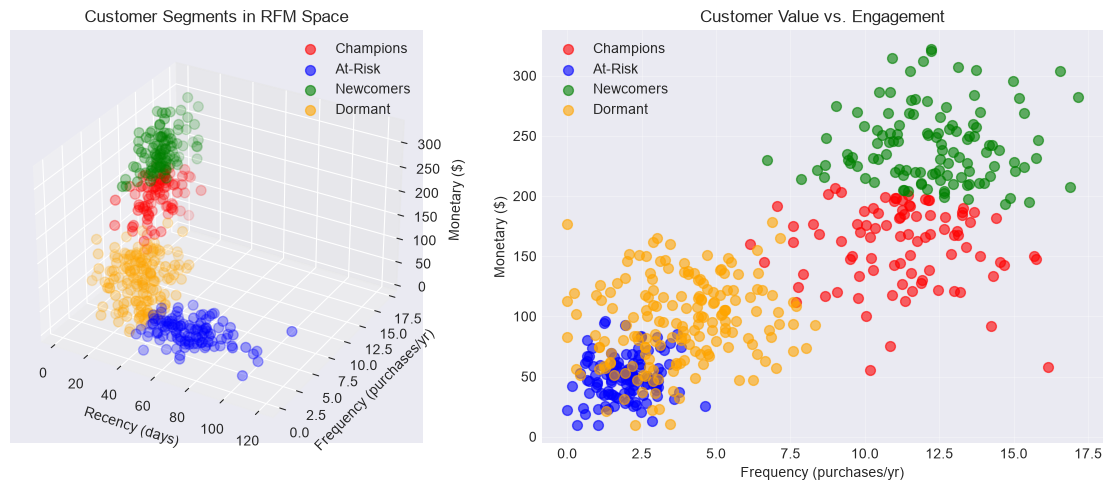

In [8]:
# 3D visualization of RFM segments
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D scatter
ax = fig.add_subplot(121, projection='3d')
colors = ['red', 'blue', 'green', 'orange']
for cluster_id, color in enumerate(colors):
    mask = rfm_data['Cluster'] == cluster_id
    ax.scatter(rfm_data[mask]['Recency'], rfm_data[mask]['Frequency'],
              rfm_data[mask]['Monetary'], c=color, label=segment_names[cluster_id],
              alpha=0.6, s=50)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (purchases/yr)')
ax.set_zlabel('Monetary (\$)')
ax.set_title('Customer Segments in RFM Space')
ax.legend()

# 2D heatmap: Frequency vs Monetary (most informative)
ax = fig.add_subplot(122)
for cluster_id, color in enumerate(colors):
    mask = rfm_data['Cluster'] == cluster_id
    ax.scatter(rfm_data[mask]['Frequency'], rfm_data[mask]['Monetary'],
              c=color, label=segment_names[cluster_id], alpha=0.6, s=50)

ax.set_xlabel('Frequency (purchases/yr)')
ax.set_ylabel('Monetary (\$)')
ax.set_title('Customer Value vs. Engagement')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a name="image-compression"></a>
## Case Study 2: Image Compression with K-Means

### The Idea

Images typically use millions of colors. We can reduce to K representative colors by:
1. Treat each pixel's RGB values as a 3D point
2. Run K-Means to find K dominant colors (centroids)
3. Replace each pixel with its nearest centroid color
4. Result: smaller file size, acceptable visual quality

In [9]:
# Create a synthetic image (gradient for reproducibility)
img_size = 200
image = np.zeros((img_size, img_size, 3), dtype=np.uint8)

# Colorful gradient
for i in range(img_size):
    for j in range(img_size):
        image[i, j, 0] = int(255 * i / img_size)      # Red channel
        image[i, j, 1] = int(255 * j / img_size)      # Green channel
        image[i, j, 2] = int(255 * (1 - i / img_size))  # Blue channel

# Reshape for clustering
pixels = image.reshape(-1, 3).astype(float)
print(f"Original image pixels: {pixels.shape[0]:,}")
print(f"Unique colors: ~{image.size // 3:,}")

Original image pixels: 40,000
Unique colors: ~40,000


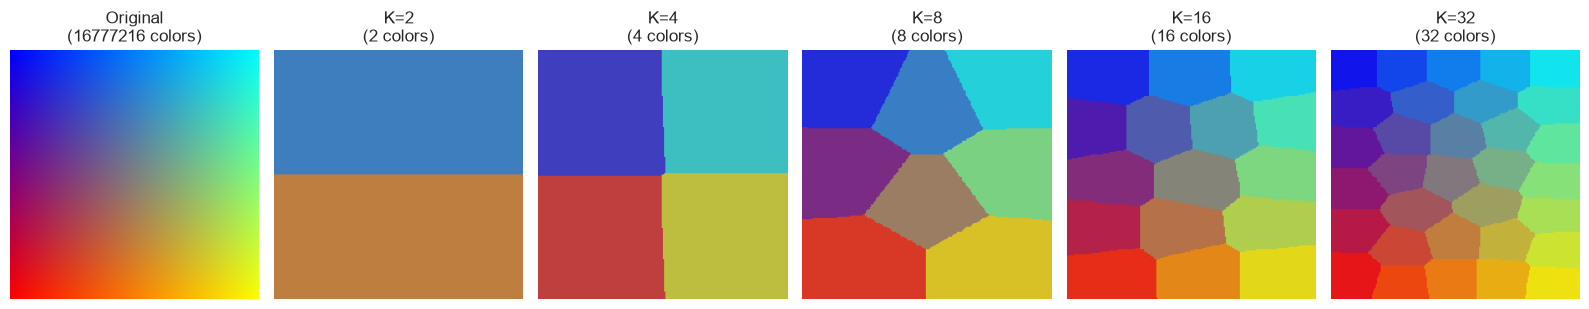

💡 Compression trade-off: fewer colors = smaller file, lower quality


In [10]:
# Compress with different K values
k_values = [2, 4, 8, 16, 32]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(16, 3))

# Original
axes[0].imshow(image)
axes[0].set_title(f'Original\n({2**24} colors)')
axes[0].axis('off')

# Compressed versions
for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, n_init=5, random_state=42, max_iter=100)
    labels = kmeans.fit_predict(pixels)
    
    # Replace pixels with centroid colors
    centroids = kmeans.cluster_centers_.astype(np.uint8)
    compressed = centroids[labels]
    compressed_img = compressed.reshape(image.shape)
    
    axes[idx + 1].imshow(compressed_img)
    axes[idx + 1].set_title(f'K={k}\n({k} colors)')
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.show()

print("💡 Compression trade-off: fewer colors = smaller file, lower quality")

<a name="minibatch"></a>
## MiniBatchKMeans for Large Datasets

In [11]:
# Generate large synthetic dataset
X_large, _ = make_blobs(n_samples=1000000, centers=10, n_features=20, random_state=42)

print(f"Dataset size: {X_large.shape}")

# Time KMeans
start = time.time()
kmeans_full = KMeans(n_clusters=10, n_init=3, random_state=42)
kmeans_full.fit(X_large)
time_full = time.time() - start

# Time MiniBatchKMeans
start = time.time()
kmeans_mini = MiniBatchKMeans(n_clusters=10, batch_size=1000, n_init=3, random_state=42)
kmeans_mini.fit(X_large)
time_mini = time.time() - start

print(f"\nStandard KMeans:")
print(f"  Time: {time_full:.3f}s")
print(f"  Inertia: {kmeans_full.inertia_:.2f}")

print(f"\nMiniBatchKMeans:")
print(f"  Time: {time_mini:.3f}s")
print(f"  Inertia: {kmeans_mini.inertia_:.2f}")

print(f"\nSpeedup: {time_full / time_mini:.1f}x faster")
print(f"Quality trade-off: {abs(kmeans_full.inertia_ - kmeans_mini.inertia_) / kmeans_full.inertia_ * 100:.1f}% worse")

Dataset size: (1000000, 20)



Standard KMeans:
  Time: 1.644s
  Inertia: 20002592.34

MiniBatchKMeans:
  Time: 0.139s
  Inertia: 20020526.91

Speedup: 11.8x faster
Quality trade-off: 0.1% worse


<a name="benchmarking"></a>
## Performance Benchmarking

### Scalability with Dataset Size

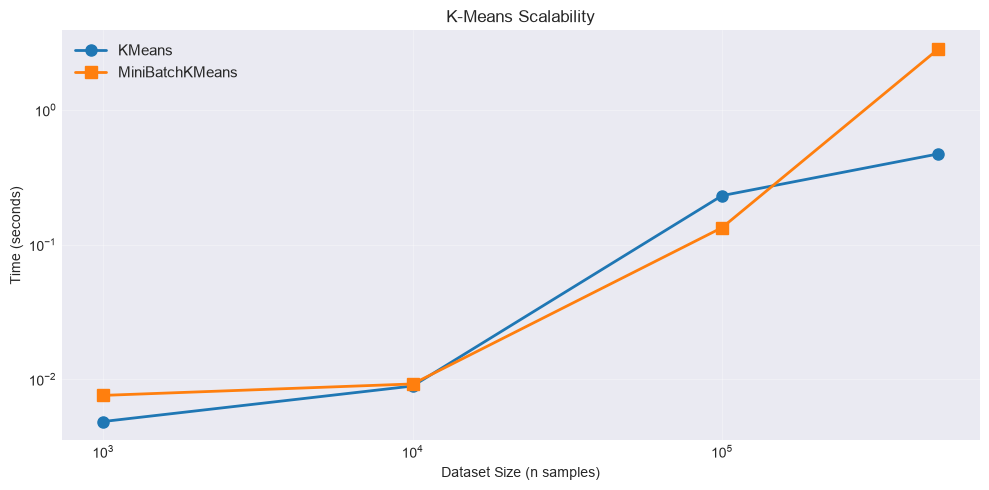

💡 MiniBatchKMeans scales much better for large datasets


In [12]:
# Benchmark different dataset sizes
sizes = [1000, 10000, 100000, 500000]
times_full = []
times_mini = []

for size in sizes:
    X, _ = make_blobs(n_samples=size, centers=5, n_features=10, random_state=42)
    
    start = time.time()
    KMeans(n_clusters=5, n_init=2, random_state=42).fit(X)
    times_full.append(time.time() - start)
    
    start = time.time()
    MiniBatchKMeans(n_clusters=5, n_init=2, random_state=42).fit(X)
    times_mini.append(time.time() - start)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sizes, times_full, 'o-', linewidth=2, markersize=8, label='KMeans')
ax.plot(sizes, times_mini, 's-', linewidth=2, markersize=8, label='MiniBatchKMeans')

ax.set_xlabel('Dataset Size (n samples)')
ax.set_ylabel('Time (seconds)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('K-Means Scalability')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 MiniBatchKMeans scales much better for large datasets")

<a name="workflows"></a>
## Complete Practical Workflow

### Best Practices Checklist

In [13]:
print("""
🔧 K-MEANS PRACTICAL WORKFLOW

1. EXPLORATORY ANALYSIS
   ☐ Load and inspect data
   ☐ Check for missing values
   ☐ Visualize distributions
   ☐ Identify outliers

2. PREPROCESSING
   ☐ Handle missing values (drop or impute)
   ☐ Scale/normalize features (StandardScaler or MinMaxScaler)
   ☐ Remove or handle outliers
   ☐ Select relevant features

3. CHOOSING K
   ☐ Try K from 2 to 10+ (depends on problem)
   ☐ Compute silhouette, Davies-Bouldin, elbow
   ☐ Domain knowledge: what makes business sense?
   ☐ Consider interpretability vs. accuracy

4. TRAINING
   ☐ Use init='k-means++' (better than random)
   ☐ Use n_init=10+ (try multiple random starts)
   ☐ Set random_state for reproducibility
   ☐ Fit on training set

5. EVALUATION
   ☐ Silhouette score (broad metric)
   ☐ Davies-Bouldin (separation & compactness)
   ☐ Visualize clusters (2D projection if high-dim)
   ☐ Check cluster sizes (should be balanced)

6. INTERPRETATION
   ☐ Analyze cluster characteristics
   ☐ Label clusters (e.g., "high-value", "at-risk")
   ☐ Identify patterns and differences
   ☐ Is the clustering actionable?

7. DEPLOYMENT
   ☐ Save scaler (needed for new data)
   ☐ Save kmeans model
   ☐ Apply to new data: scaler.transform() → kmeans.predict()
   ☐ Monitor: are new data distributions drifting?
""")


🔧 K-MEANS PRACTICAL WORKFLOW

1. EXPLORATORY ANALYSIS
   ☐ Load and inspect data
   ☐ Check for missing values
   ☐ Visualize distributions
   ☐ Identify outliers

2. PREPROCESSING
   ☐ Handle missing values (drop or impute)
   ☐ Scale/normalize features (StandardScaler or MinMaxScaler)
   ☐ Remove or handle outliers
   ☐ Select relevant features

3. CHOOSING K
   ☐ Try K from 2 to 10+ (depends on problem)
   ☐ Compute silhouette, Davies-Bouldin, elbow
   ☐ Domain knowledge: what makes business sense?
   ☐ Consider interpretability vs. accuracy

4. TRAINING
   ☐ Use init='k-means++' (better than random)
   ☐ Use n_init=10+ (try multiple random starts)
   ☐ Set random_state for reproducibility
   ☐ Fit on training set

5. EVALUATION
   ☐ Silhouette score (broad metric)
   ☐ Davies-Bouldin (separation & compactness)
   ☐ Visualize clusters (2D projection if high-dim)
   ☐ Check cluster sizes (should be balanced)

6. INTERPRETATION
   ☐ Analyze cluster characteristics
   ☐ Label clusters

<a name="conclusion"></a>
## Conclusion

### What You've Learned

1. **scikit-learn API**: How to use KMeans with proper parameters (init, n_init, random_state)

2. **Feature Scaling**: Standardization is crucial when features have different units/scales

3. **Real-world Applications**:
   - Customer segmentation (RFM analysis) for targeted marketing
   - Image compression (color quantization)
   - And many others (document clustering, anomaly detection, pre-processing)

4. **Choosing K**: Multiple metrics + domain knowledge = best decision

5. **Scalability**: MiniBatchKMeans for large datasets (100k+ samples)

6. **Practical Workflow**: Preprocess → choose K → train → evaluate → interpret → deploy

### Key Takeaway

K-Means is **simple, fast, and practical**. It's often the first clustering algorithm to try:
- ✅ Fast (O(nKdi) time)
- ✅ Scales well (MiniBatchKMeans for big data)
- ✅ Easy to interpret (centroids are real points)
- ⚠️ Assumes spherical clusters
- ⚠️ Sensitive to K choice and initialization
- ⚠️ Affected by outliers

### Next Lessons

When K-Means isn't enough:
- **Hierarchical Clustering (Lesson 2)**: Don't fix K upfront; discover nested structure
- **DBSCAN (Lesson 3)**: Handle arbitrary shapes and noise
- **Gaussian Mixture Models (Lesson 4)**: Probabilistic assignments; model data distribution

Congratulations! You've completed the K-Means story: theory, implementation, and practical applications. 🎉